# Miscellaneous Analyses

## Purpose: 

This is meant for mini-analyses and questions that need answered that don't fall into the normal workflow. 

## Packages and Options

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob, pickle, seaborn  
import matplotlib.pyplot as plt

import networkx

## Confirm that the relative scores from `JASPAR 2022` are ranks

In [2]:
rank_observation_num_differences = []

for file in glob.glob("2_get_data/outputs/*"): 
    
    tmp_df = pd.read_csv(file, sep="\t", header=None)
    tmp_df = tmp_df[[4]]
        
    if tmp_df[4].min()!=800: 
        "Min not 800 {}".format(file)
        tmp_df[4].min()
        
    if tmp_df[4].max()!=1000: 
        "Max not 1000 {}".format(file)
        tmp_df[4].max()
    
    rank_observation_num_differences.append(
        
            (tmp_df[tmp_df[4]<900].index.size) - (tmp_df[tmp_df[4]>900].index.size)
        
    )

'Max not 1000 2_get_data/outputs/MA1114.1.tsv'

998

<Figure size 900x600 with 0 Axes>

/apps/software/standard/compiler/gcc/9.2.0/jupyter_conda/2020.11-py3.8/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

Text(0.5, 0.98, 'Difference Between Number of JASPAR \n Predictions with Relative Score < 900 and > 900 \n 24 dots correspond to 24 TFs and ideally this should be 24 zeros')

(-0.1, 0.1)

Text(0.5, 0, 'Absolute Value Difference')

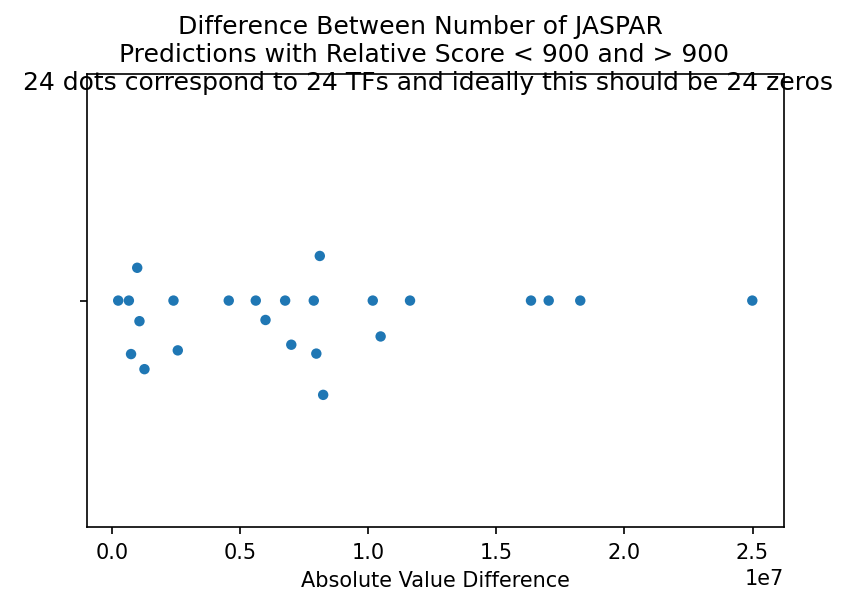

In [10]:
plt.figure(dpi=150)

seaborn.swarmplot(rank_observation_num_differences)

plt.suptitle("Difference Between Number of JASPAR \n Predictions with Relative Score < 900 and > 900 \n 24 dots correspond to 24 TFs and ideally this should be 24 zeros")

plt.ylim(-0.1, 0.1)

plt.xlabel("Absolute Value Difference")

Oh no!!! Looks like they're not ranks as we expected. 

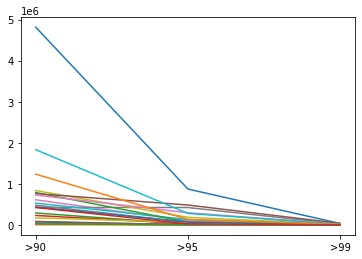

In [17]:
labels=[">90", ">95", ">99"]


for file in glob.glob("2_get_data/outputs/*"): 
    
    tmp_df = pd.read_csv(file, sep="\t", header=None)
    tmp_df = tmp_df[[4]]
    
    line = [tmp_df[tmp_df[4]>900].index.size, tmp_df[tmp_df[4]>950].index.size, tmp_df[tmp_df[4]>990].index.size]
    
    plt.plot(labels, line)

plt.show()

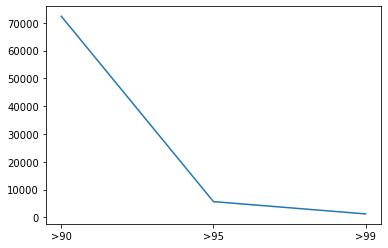

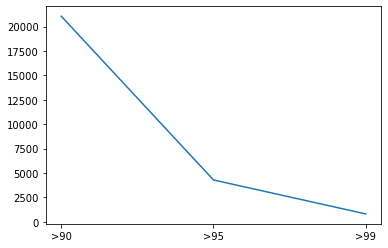

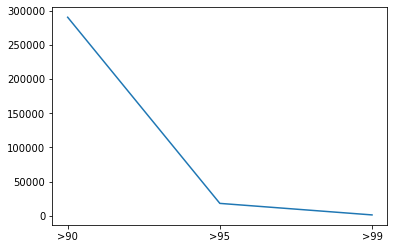

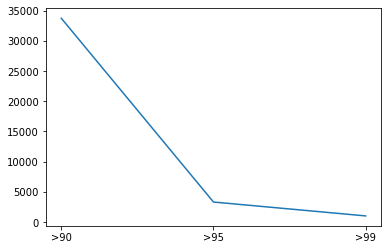

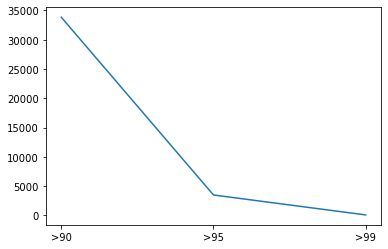

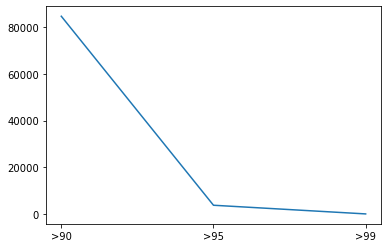

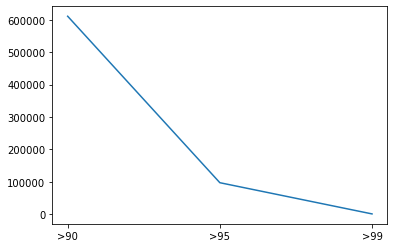

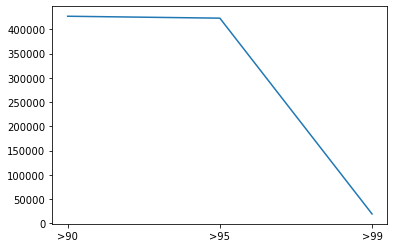

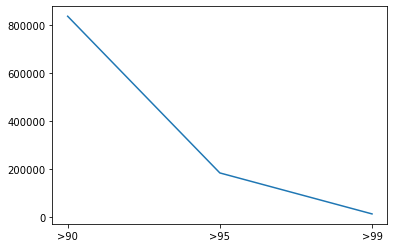

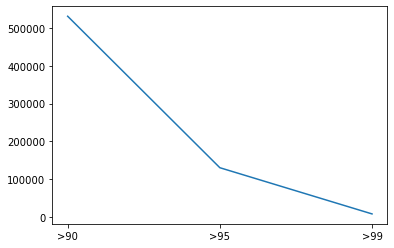

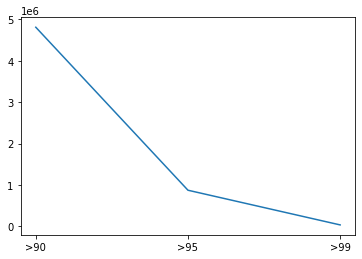

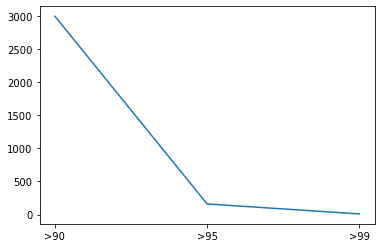

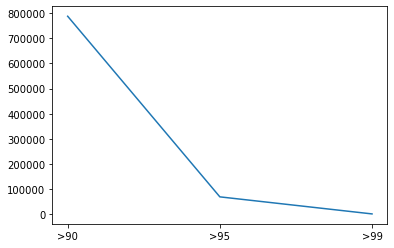

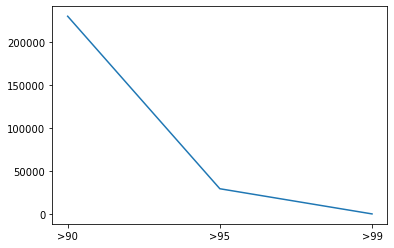

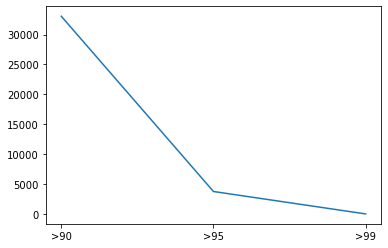

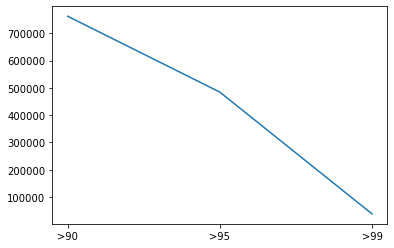

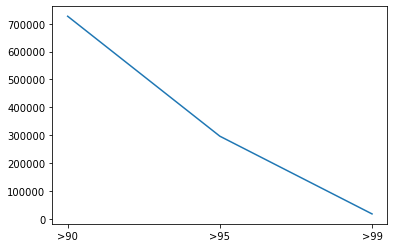

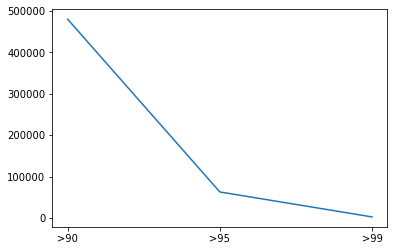

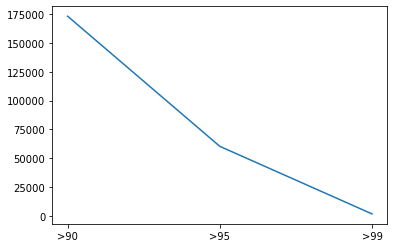

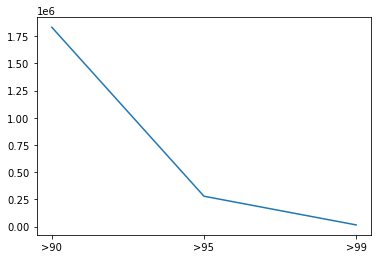

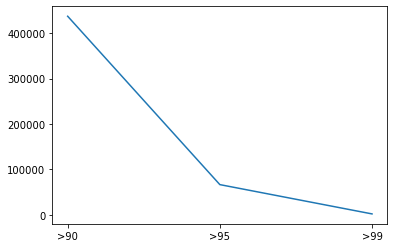

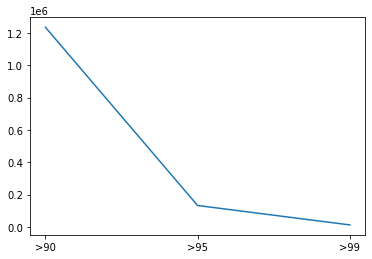

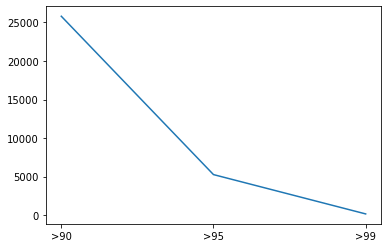

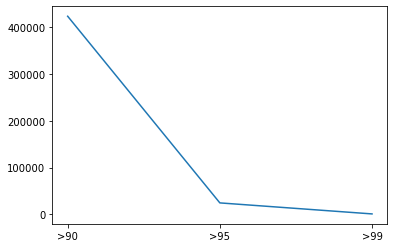

In [18]:
labels=[">90", ">95", ">99"]


for file in glob.glob("2_get_data/outputs/*"): 
    
    tmp_df = pd.read_csv(file, sep="\t", header=None)
    tmp_df = tmp_df[[4]]
    
    line = [tmp_df[tmp_df[4]>900].index.size, tmp_df[tmp_df[4]>950].index.size, tmp_df[tmp_df[4]>990].index.size]
    
    plt.plot(labels, line)
    
    plt.show()

## Load Differential Expression Genes-TF Networks

In [4]:
files = glob.glob("../../outputs/pickled_networks/differential_expression_tf_networks/*")

files

['../../outputs/pickled_networks/differential_expression_tf_networks/upstream_2500_score_950.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_5000_score_950.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_750_score_900.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_750_score_990.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_2500_score_990.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_5000_score_990.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_5000_score_900.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_750_score_950.networkx_graph',
 '../../outputs/pickled_networks/differential_expression_tf_networks/upstream_2500_score_900.networkx_graph']

In [5]:
diff_expression_tf_networks = {}

for file in files:
    
    parameter_combination = file.split("/")[-1].split(".")[0]
    diff_expression_tf_networks[parameter_combination] = pickle.load(open(file, 'rb'))
    
    

In [6]:
for key in diff_expression_tf_networks: 
    diff_expression_tf_networks[key]

## Retrieve the following summary statistics for each parameter combination:
* Total nodes in network
* Number of "TFs of interest" from Muge (out of 24)
* Weak and strong connected components: 
    * Number of nodes in each type

In [7]:
# initialize all the lists 
parameter_combinations = []
total_nodes = []
tfs_of_interest = []
num_strongly_connected_components = []
num_weakly_connected_components = []
num_nodes_strongly_connected_components = []
num_nodes_weakly_connected_components=[]

for key in diff_expression_tf_networks: 
    
    tmp = diff_expression_tf_networks[key]
    
    parameter_combinations.append(key)
    
    total_nodes.append(tmp.number_of_nodes())
    
    candidate_tf_list = []
    
    for edge in tmp.edges(): 
        candidate_tf_list.append(edge[0])
    
    tfs_of_interest = len(set(candidate_tf_list))
    
    num_strongly_connected_components.append(networkx.number_strongly_connected_components(tmp))
    num_weakly_connected_components.append(networkx.number_weakly_connected_components(tmp))
    

In [11]:
summary = pd.DataFrame(
    {
        "Parameter Combination": parameter_combinations,
        "Total Nodes in Network": total_nodes, 
        "TFs from Muge (24 total)": tfs_of_interest, 
        "Number of Strongly Connected Components": num_strongly_connected_components, 
        "Number of Weakly Connected Components": num_weakly_connected_components, 
        
    }, 
)

summary = summary.sort_values(["Parameter Combination"])

summary

,Parameter Combination,Total Nodes in Network,TFs from Muge (24 total),Number of Strongly Connected Components,Number of Weakly Connected Components
8,upstream_2500_score_900,325,24,316,1
0,upstream_2500_score_950,322,24,315,1
4,upstream_2500_score_990,196,24,196,2
6,upstream_5000_score_900,325,24,316,1
1,upstream_5000_score_950,325,24,317,1
5,upstream_5000_score_990,236,24,235,1
2,upstream_750_score_900,325,24,317,1
7,upstream_750_score_950,313,24,306,1
3,upstream_750_score_990,131,24,131,3


In [9]:
summary.to_csv("/home/jve4pt/network_summary_stats.tsv", sep="\t")